In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pylab import *
from sklearn.preprocessing import MinMaxScaler
from sklearn import svm, datasets

In [6]:
# criando dados falsos de dinheiro por idade para n pessoas com k clusters
def createClusteredData(N, k):

    # reproduzibilidade
    np.random.seed(1234)

    # número de pontos por cluster
    pointsPerCluster = float(N) / k

    # listas de dados e rótulos
    X = []
    y = []

    # criando os clusters
    for i in range(k):

        # centroides aleatórios
        incomeCentroid = np.random.uniform(20000.0, 200000.0)
        ageCentroid = np.random.uniform(20.0, 70.0)

        # criando os pontos ao redor dos centroides
        for j in range(int(pointsPerCluster)):
            X.append([np.random.normal(incomeCentroid, 10000.0), np.random.normal(ageCentroid, 2.0)])
            y.append(i)
    
    # convertendo para arrays numpy
    X = np.array(X)
    y = np.array(y)

    return X, y

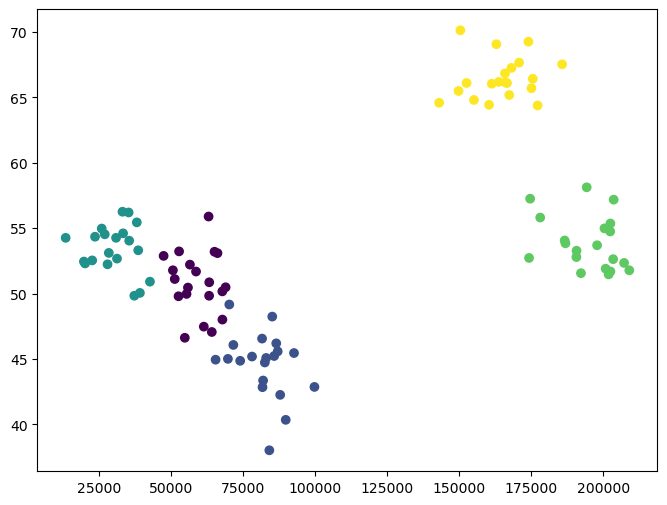

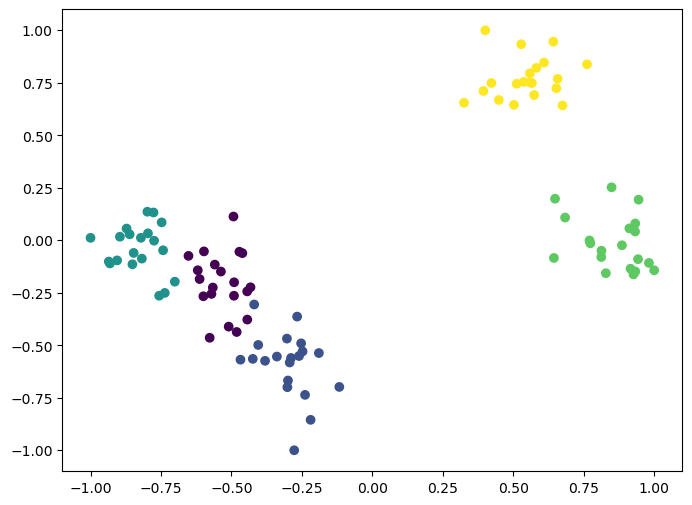

In [10]:
# criando dados falsos
(X, y) = createClusteredData(100, 5)

# plotando os dados
plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=y.astype(np.float64))
plt.show()

# escalando os dados
scaling = MinMaxScaler(feature_range=(-1, 1)).fit(X)
X = scaling.transform(X)

# plotando os dados escalados
plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=y.astype(np.float64))
plt.show()

In [ ]:
# treinando o classificador SVM
C = 1.0

svc = svm.SVC(kernel='linear', C=C).fit(X, y)

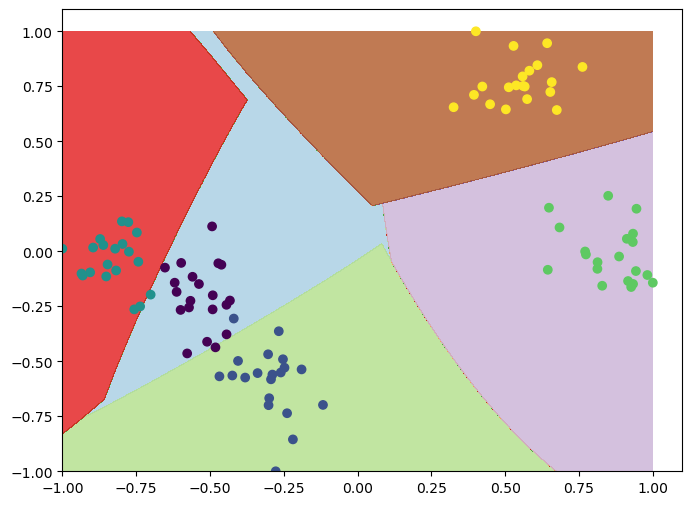

In [15]:
def plotPredictions(clf):

    # criando uma grade de pontos
    xx, yy = np.meshgrid(np.arange(-1, 1, .001),
                         np.arange(-1, 1, .001)
                         )
    
    # convertendo para arrays numpy
    npx = xx.ravel()
    npy = yy.ravel()

    # converte para uma lista 2d de pontos
    samplePoints = np.c_[npx, npy]

    # fazendo as previsões
    Z = clf.predict(samplePoints)

    plt.figure(figsize=(8,6))
    Z = Z.reshape(xx.shape) # reshape para o formato da grade
    plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.8) # plotando as regiões
    plt.scatter(X[:, 0], X[:, 1], c=y.astype(np.float64)) # plotando os pontos de dados
    plt.show()

plotPredictions(svc)


## Activity

"Linear" is one of many kernels scikit-learn supports on SVC. Look up the documentation for scikit-learn online to find out what the other possible kernel options are. Do any of them work well for this data set?

In [14]:
svc = svm.SVC(kernel='rbf', C=C).fit(X, y)